In [1]:
import pandas as pd

from utils.config import load_config
from preprocessing.house_prices_preprocessing import HousePricesPreprocessor
from models.advanced.regression import run_advanced_regression
from models.advanced.training_history import show_training_history

In [2]:
config = load_config()

data = pd.read_csv(config["paths"]["train"])

print("Data shape:", data.shape)

# --- разделяем target ---
target = "SalePrice"

y = data[target]
X = data.drop(columns=[target])

# --- preprocessing ---
preprocessor = HousePricesPreprocessor(outlier_quantile=0.95)

X_prepared = preprocessor.fit_transform(X)

X_prepared.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageFinish_Unf,GarageFinish_Fin,GarageFinish_None,BsmtFinType1_GLQ,BsmtFinType1_ALQ,BsmtFinType1_Unf,BsmtFinType1_Rec,BsmtFinType1_BLQ,BsmtFinType1_None,BsmtFinType1_LwQ
0,0.073375,-0.208804,-0.332210,0.651479,-0.517200,1.050994,0.878668,0.739648,0.667140,-0.327561,...,0,0,0,1,0,0,0,0,0,0
1,-0.872563,0.646406,-0.009592,-0.071836,2.179628,0.156734,-0.429577,-0.654947,1.327216,-0.327561,...,0,0,0,0,1,0,0,0,0,0
2,0.073375,-0.037762,0.453294,0.651479,-0.517200,0.984752,0.830215,0.497729,0.133255,-0.327561,...,0,0,0,1,0,0,0,0,0,0
3,0.309859,-0.493874,-0.023619,0.651479,-0.517200,-1.863632,-0.720298,-0.654947,-0.521967,-0.327561,...,1,0,0,0,1,0,0,0,0,0
4,0.073375,0.874462,1.297710,1.374795,-0.517200,0.951632,0.733308,1.835402,0.543376,-0.327561,...,0,0,0,1,0,0,0,0,0,0


In [3]:
advanced_results = run_advanced_regression(
    X_prepared,
    y,
    with_history=True,
)

In [4]:
advanced_results['metrics']

,model,MAE,MSE,RMSE,R2
0,XGBoost,15048.479492,6.686995e+08,25859.225046,0.912820
1,GradientBoosting,16051.175051,7.245492e+08,26917.451151,0.905539
2,CatBoost,15748.995294,7.702951e+08,27754.190324,0.899575
3,ExtraTrees,17648.255574,8.243277e+08,28711.107754,0.892530
4,LightGBM,17265.222647,8.800052e+08,29664.881386,0.885271
5,Bagging,18138.320560,9.136479e+08,30226.609736,0.880885
6,RandomForest,17834.819049,9.202508e+08,30335.635740,0.880025


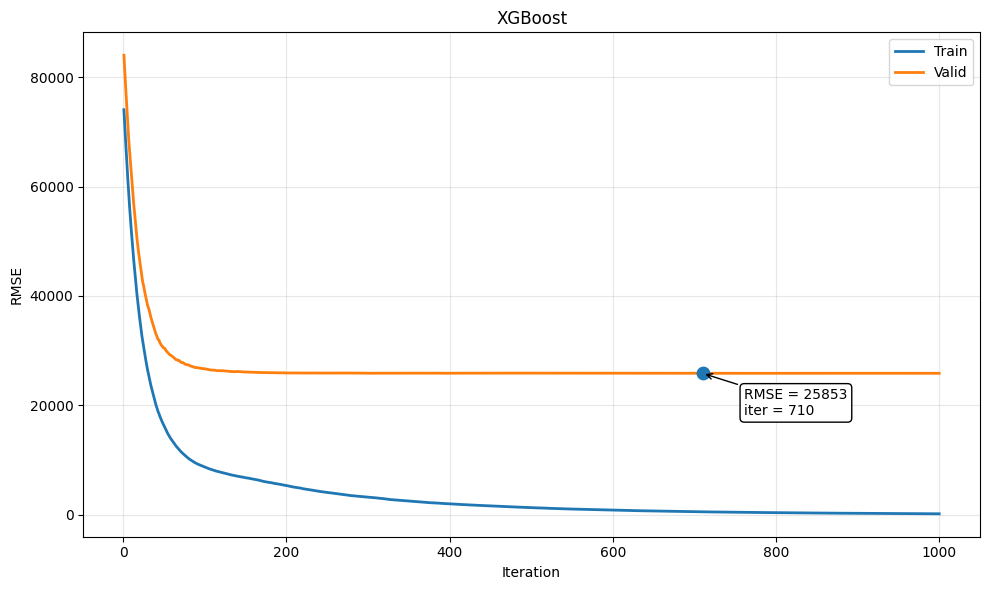

In [5]:
show_training_history(
    advanced_results["training_history"]["XGBoost"],
    model_name="XGBoost",
)

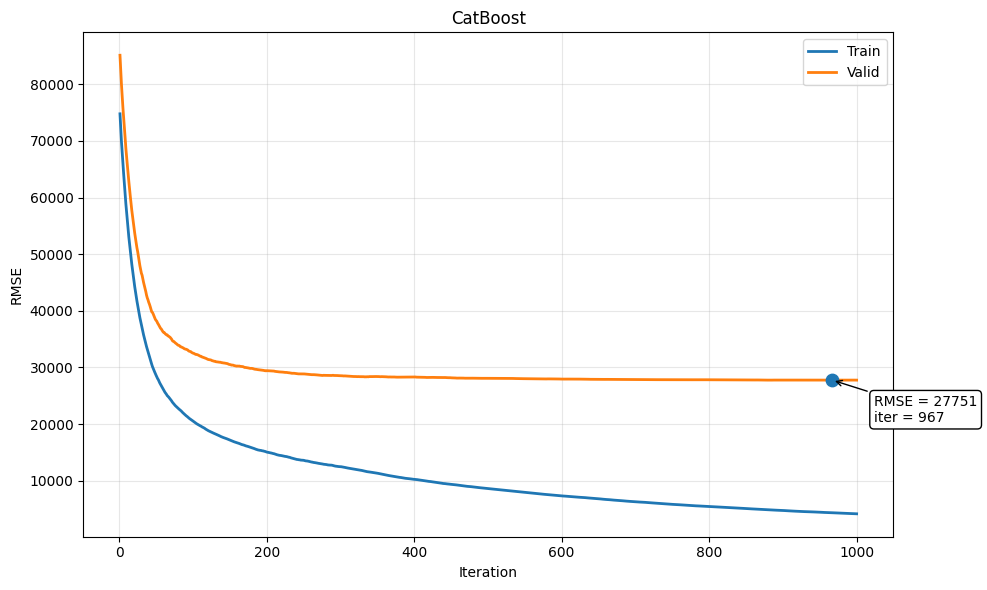

In [6]:
show_training_history(
    advanced_results["training_history"]["CatBoost"],
    model_name="CatBoost",
)

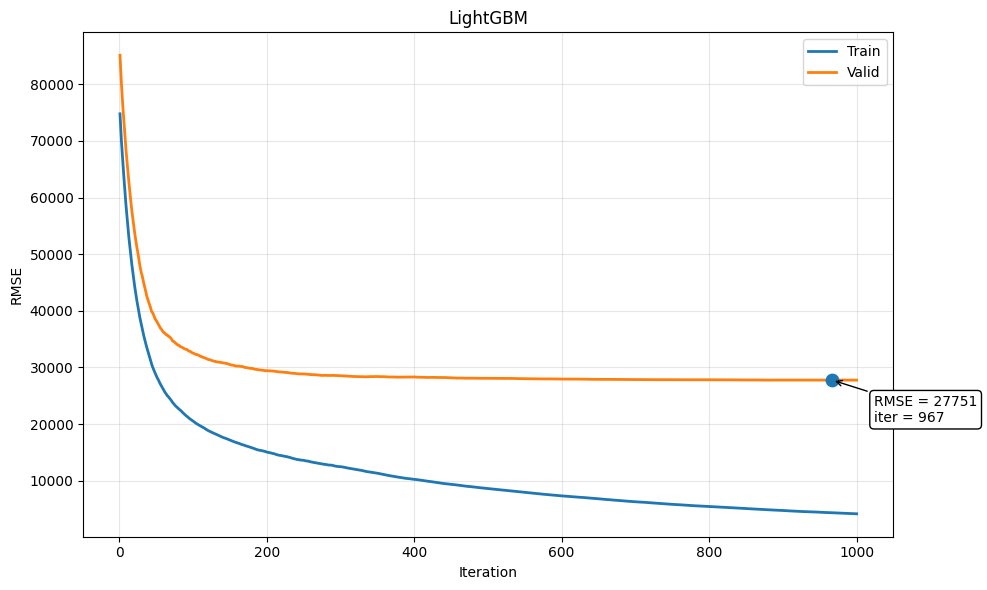

In [7]:
show_training_history(
    advanced_results["training_history"]["CatBoost"],
    model_name="LightGBM",
)

# Advanced модели: результаты и выводы

## Задача

Предсказать цену дома (`SalePrice`) на основе признаков.

---

## Результаты advanced моделей

| Model            | MAE     | RMSE       | R²        |
| ---------------- | ------- | ---------- | --------- |
| XGBoost          | ~15 048 | **25 859** | **0.913** |
| GradientBoosting | ~16 051 | 26 917     | 0.906     |
| CatBoost         | ~15 749 | 27 754     | 0.900     |
| ExtraTrees       | ~17 648 | 28 711     | 0.893     |
| LightGBM         | ~17 265 | 29 665     | 0.885     |
| Bagging          | ~18 138 | 30 227     | 0.881     |
| RandomForest     | ~17 835 | 30 336     | 0.880     |

---

## Интерпретация

### 1. Сравнение с baseline

Лучшая baseline модель:

* **Ridge**
* RMSE ≈ **33 076**

Лучшая advanced модель:

* **XGBoost**
* RMSE ≈ **25 859**

Улучшение:

* примерно на **7 200**
* это около **22% улучшения по RMSE**

Это означает, что ансамблевые методы и бустинг заметно лучше улавливают нелинейные зависимости в данных, чем линейные baseline модели.

---

### 2. Лучшая модель

Лучший результат показал:

* **XGBoost**
* RMSE ≈ **25 859**
* R² ≈ **0.913**

Это уже сильный результат для табличной задачи такого типа.

---

### 3. Ошибка модели

Средняя цена дома:

* **≈ 180 000**

Ошибка XGBoost:

* **≈ 25 900**

Приблизительно:

[
Ошибка \approx 14\%
]

Это уже заметно лучше baseline, где ошибка была около **18%**.

---

### 4. R²

Для XGBoost:

[
R^2 = 0.913
]

Модель объясняет примерно **91% вариации цены дома**.

Это означает, что модель уже хорошо описывает структуру данных.

---

## Что показали графики обучения

По history бустингов видно:

* train error продолжает уменьшаться
* valid error быстро падает в начале
* потом почти выходит на плато

Это означает:

* модель действительно учится
* основной прирост качества происходит на первых сотнях итераций
* дальше улучшение становится слабее
* есть риск переобучения при слишком большом числе деревьев

Особенно это видно у XGBoost и CatBoost: после некоторого момента валидационная ошибка почти не улучшается.

---

## Выводы

* advanced модели заметно лучше baseline
* лучший результат показал **XGBoost**
* бустинг оказался сильнее bagging и случайных лесов
* задача хорошо решается классическими ML-моделями на табличных данных
* текущий уровень качества уже достаточно высокий

---

# Новая планка качества

## Baseline

* RMSE ≈ **33 000**

## Advanced

* RMSE ≈ **25 900**

## Новая целевая планка

* улучшение до **RMSE < 25 000**